# The Waffle House Index — a quantitative teardown 🔬
### A market-adjusted event study · a paired rebuilders−insurers directional test · a 20-seed random-calendar placebo · the [−10..+20] anatomy and its look-elsewhere caveat · a costed long-short timer · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Index%3F: Busted](https://img.shields.io/badge/Index%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim: a major US hurricane should *dip* listed P&C insurers (ALL/TRV/PGR, payout shock) and *rally* home-improvement names (HD/LOW, rebuild demand) — with the sceptic's prior that a **forecast** event is already priced by landfall. The job here is to measure it honestly on today's tradable tape, then ask the only question that pays: *is any of it real, and if so, tradable?*

> ⚠️ **Data note.** SPY + ALL/TRV/PGR/HD/LOW total-return closes (2004→2026), yfinance, cached; **16 hardcoded major US hurricane landfalls** 2005→2024 (NHC/NOAA public dates). Survivorship named on the Signal axis (surviving large-caps, not the full P&C universe). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `06c89e09c7e9` SPY / `3eba4d87a095` ALL / `1d9d0f43fbd0` TRV / `9730d67197d9` PGR / `60093d13105c` HD / `73373520bb2e` LOW).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from waffle_index import data, strategy as st

EVENTS = data.disaster_table()
HAVE_REAL = data.have_real()
PRE, POST, LO, HI = 10, 20, 0, 20
if HAVE_REAL:
    CLOSES = data.load_real()
    SPY = CLOSES["SPY"]
    AR_INS = st.basket_ar(CLOSES, data.INSURERS, SPY)
    AR_REB = st.basket_ar(CLOSES, data.REBUILDERS, SPY)
else:
    CLOSES = SPY = AR_INS = AR_REB = None
print("real cache present:", HAVE_REAL, "| hurricanes in table:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 16, 'cal_lo': '2005-08-29', 'cal_hi': '2024-10-09', 'ins_car': 1.15, 'ins_t': 1.48, 'ins_nw': 1.63, 'ins_down': 6, 'ins_down_pct': 37.5, 'ins_wilson': (18.5, 61.4), 'reb_car': -0.28, 'reb_t': -0.25, 'reb_nw': -0.37, 'reb_up': 8, 'reb_up_pct': 50.0, 'reb_wilson': (28.0, 72.0), 'ls_spread': -1.43, 'ls_t': -0.88, 'ls_nw': -1.06, 'ls_ci': (-4.32, 1.62), 'plc_ins_mean': 0.26, 'plc_ins_sd': 1.03, 'plc_ins_p': 0.385, 'plc_reb_mean': 0.28, 'plc_reb_sd': 1.31, 'plc_reb_p': 0.662, 'plc_ls_mean': 0.04, 'plc_ls_sd': 1.67, 'plc_ls_p': 0.379, 'offsets': [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'ins_path': [0.0, 0.0, 0.27, 0.47, 0.83, 0.26, 0.19, 0.37, -0.36, 0.05, 0.0, 0.09, 0.02, 0.23, 0.39, 0.22, 0.63, 0.64, 0.32, 0.65, 0.84, 1.3, 1.13, 1.55, 1.81, 2.27, 1.4, 0.93, 1.28, 1.23, 1.2], 'reb_path': [0.0, -0.1, 0.77, 0.83, 0.96, 0.98, 1.11, 1.28, 1.57, 1.28, 1.71, 1.35, 1.32, 1.65, 1.52, 1.34, 1.14, 1.26, 1.51, 2.06, 2.27, 1.46, 1.27, 1.35, 1.04, 0.78, 0.81, 0.92, 1.41, 1.57, 1.0], 'ins_m5_t': -2.77, 'tier3_n': 7, 'tier3_ins': -0.28, 'tier3_ins_t': -0.36, 'tier3_reb': 3.09, 'tier3_reb_t': 2.02, 'tier3_ls': 3.36, 'tier3_ls_t': 1.64, 'pre15_n': 5, 'pre15_ls': -0.03, 'pre15_t': -0.01, 'post15_n': 11, 'post15_ls': -2.06, 'post15_t': -1.0, 'timer': {5: (-57.8, -78.8, -0.82, 38), 10: (-22.2, -44.2, -0.41, 44), 20: (-153.3, -177.2, -1.22, 25)}, 'syn_null_mean': -0.12, 'syn_null_sd': 1.19, 'syn_null_fire': 2, 'syn_planted_t': 3.42, 'syn_planted_ins_t': -2.64, 'syn_planted_reb_t': 1.81, 'syn_planted_spread': 2.85, 'fp_spy': '06c89e09c7e9', 'fp_all': '3eba4d87a095', 'fp_trv': '1d9d0f43fbd0', 'fp_pgr': '9730d67197d9', 'fp_hd': '60093d13105c', 'fp_low': '73373520bb2e'}


real cache present: True | hurricanes in table: 16


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | insurers CAR **+1.15%** (*t* = +1.48), rebuilders **-0.28%** (*t* = -0.25) — both wrong sign; paired spread **-1.43%** (*t* = -0.88), placebo *p* = 0.379 |
| **Tradability** | `MIRAGE` | long-reb/short-ins loses every horizon (5/10/20d), worst net **-177 bps** (*t* = -1.22) |
| **Waffle House Index in prices?** | `BUSTED` | forecast event, priced pre-landfall; n=16 low power |

> 💡 In plain words: two legs with genuine fundamental mechanisms, and the modern tradable test comes back empty — even *backwards* — on every axis.

## 1 · The claim, steelmanned

Let $r^i_t$ be name $i$'s daily return and $m_t$ SPY's; the market-adjusted abnormal return is $a^i_t = r^i_t - m_t$ (Brown & Warner 1985, market-adjusted model — an implicit $\beta=1$, standard for short windows). For each landfall $\tau_e$, take the equal-weight basket abnormal return $a^{ins}$, $a^{reb}$ and the per-event CAR $C^b_e = \sum_{k=0}^{20} a^b_{\tau_e + k}$. The claims:

- **H₁ (insurer dip).** $E[C^{ins}_e] < 0$, systematic across events.
- **H₂ (rebuilder rally).** $E[C^{reb}_e] > 0$.
- **H₃ (directional spread).** $E[C^{reb}_e - C^{ins}_e] > 0$ — the paired, cleanest one-number test.
- **H₄ (capture).** A long-reb/short-ins book, entered at the landfall close, beats zero net of costs.

We find **H₁ rejected on sign** (+1.15%, *t* = +1.48), **H₂ rejected on sign** (−0.28%, *t* = −0.25), **H₃ rejected on sign** (−1.43%, *t* = −0.88), **H₄ not supported** (negative net at every horizon).

## 2 · So what? — inference design

Landfalls are **independent, far-apart calendar dates** (weeks to years apart), so the planned primary is a **one-sample t-test** across the 16 per-event CARs — the unit of analysis is already "one number per event", not a daily series, so no HAC correction is needed the way a daily-panel regression would require (a Newey-West *t* is reported anyway and auto-falls-back to a plain *t* below n=8). The hit rate carries a **Wilson** interval; the placebo draws 16 random non-disaster dates **20,000 times** (20 seeds × 1,000); the [−10..+20] anatomy is read as a **31-offset multiple-comparison** exercise; H₃ **pairs** each event's two baskets on the same window so any residual common shock cancels. The window is wide on the *pre*-landfall side because a hurricane is **forecast** — anticipation is part of the hypothesis, not a nuisance.

## 3 · How we'd know — the protocol

- **Calendar.** 16 major US hurricane landfalls 2005-08-29 → 2024-10-09, hardcoded (NHC/NOAA). All 16 sit on the tape.
- **Tape.** SPY + ALL/TRV/PGR/HD/LOW total-return closes, 2004 → 2026-06-30 (as-of, last complete month). All six trade the full window.
- **Abnormal return.** Market-adjusted (name − SPY), equal-weight baskets.
- **Headline.** Per-event CAR [+0..+20], one-sample + NW *t*, Wilson hit rate, 20-seed placebo — for insurers, rebuilders, and the paired spread.
- **Anatomy.** CAR path [−10..+20], per-offset *t*, read with the multiple-comparison caveat.
- **Robustness.** Catastrophic-only (loss-tier 3, n=7) and a pre-/post-2015 era split.
- **Execution (timer).** Enter long-reb/short-ins at the landfall close (zero look-ahead — landfall is forecast and calendar-known), exit `hold` sessions later; one-way cost × NAV on all 4 legs + borrow on the short leg.
- **Control.** Synthetic world, planted insurer-down/rebuilder-up drift; the null must not systematically fire across 20 seeds.

## 4 · The teardown

### 4a · The headline CARs and the paired spread

One-sample *t* on each basket's per-event CAR, plus the paired rebuilders−insurers spread (H₃) with an event-bootstrap CI.

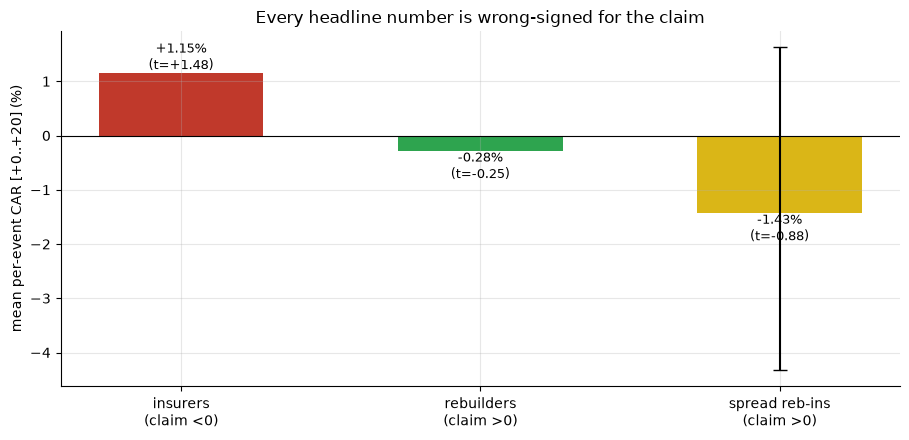

insurers +1.15% (t=+1.48); rebuilders -0.28% (t=-0.25)
spread -1.43% (t=-0.88), boot 95% CI [-4.32%, +1.62%]


In [2]:
if HAVE_REAL:
    ins = st.car_stats(AR_INS, EVENTS['date'], PRE, POST, LO, HI)
    reb = st.car_stats(AR_REB, EVENTS['date'], PRE, POST, LO, HI)
    ls = st.long_short_stats(AR_INS, AR_REB, EVENTS['date'], PRE, POST, LO, HI)
    lo, hi = st.block_bootstrap_ci(ls['diff'])
    ins_c, ins_t = ins['mean']*100, ins['t']
    reb_c, reb_t = reb['mean']*100, reb['t']
    ls_c, ls_t = ls['mean_diff']*100, ls['t']; ci = (lo*100, hi*100)
else:
    ins_c, ins_t = R['ins_car'], R['ins_t']
    reb_c, reb_t = R['reb_car'], R['reb_t']
    ls_c, ls_t = R['ls_spread'], R['ls_t']; ci = R['ls_ci']
fig, ax = plt.subplots(figsize=(9.2, 4.5))
labels = ['insurers\n(claim <0)', 'rebuilders\n(claim >0)', 'spread reb-ins\n(claim >0)']
vals = [ins_c, reb_c, ls_c]; cols = [RED, GREEN, AMBER]
b = ax.bar(labels, vals, color=cols, width=.55)
ax.errorbar(2, ls_c, yerr=[[ls_c-ci[0]], [ci[1]-ls_c]], fmt='none', ecolor='k', capsize=5)
for bb, v, t in zip(b, vals, [ins_t, reb_t, ls_t]):
    ax.annotate(f'{v:+.2f}%\n(t={t:+.2f})', (bb.get_x()+bb.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean per-event CAR [+0..+20] (%)')
ax.set_title('Every headline number is wrong-signed for the claim')
plt.tight_layout(); plt.show()
print(f'insurers {ins_c:+.2f}% (t={ins_t:+.2f}); rebuilders {reb_c:+.2f}% (t={reb_t:+.2f})')
print(f'spread {ls_c:+.2f}% (t={ls_t:+.2f}), boot 95% CI [{ci[0]:+.2f}%, {ci[1]:+.2f}%]')

> 💡 In plain words: H₁ wants insurers **down** — they're **+1.15%** (*t* = +1.48). H₂ wants rebuilders **up** — they're **-0.28%** (*t* = -0.25). H₃ wants the spread **positive** — it's **-1.43%** (*t* = -0.88), CI [-4.32%, +1.62%]. Three predictions, three wrong signs, none significant.

### 4b · The random-calendar placebo

Draw 16 random non-disaster dates and recompute each CAR; repeat 20,000 times. If the observed number sits in the bulk, a random calendar of the same size produces it anyway. In the notebook we run a lighter placebo (4 seeds × 500) and quote the canonical 20,000-draw *p* from `results.md`.

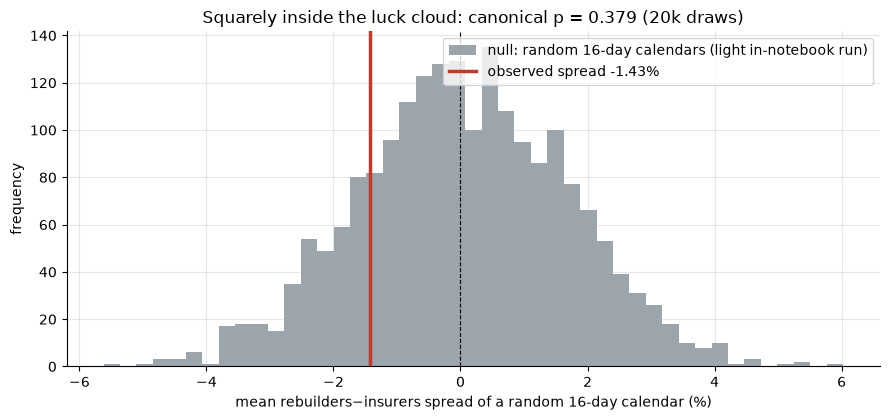

canonical placebo (results.md): insurers p=0.385, rebuilders p=0.662, spread p=0.379


In [3]:
if HAVE_REAL:
    ls = st.long_short_stats(AR_INS, AR_REB, EVENTS['date'], PRE, POST, LO, HI)
    obs = ls['mean_diff']
    dr_r = np.concatenate([st.placebo_distribution(AR_REB, ls['n'], PRE, POST, LO, HI,
               n_draws=500, seed=1843+s) for s in range(4)])
    dr_i = np.concatenate([st.placebo_distribution(AR_INS, ls['n'], PRE, POST, LO, HI,
               n_draws=500, seed=843+s) for s in range(4)])
    draws = dr_r - dr_i
else:
    obs = R['ls_spread'] / 100
    rng = np.random.default_rng(843)
    draws = rng.normal(R['plc_ls_mean']/100, R['plc_ls_sd']/100, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=45, color=GREY, alpha=.85,
        label='null: random 16-day calendars (light in-notebook run)')
ax.axvline(obs*100, c=RED, lw=2.5, label=f'observed spread {obs*100:+.2f}%')
ax.axvline(0, c='k', lw=.8, ls='--')
ax.set_xlabel('mean rebuilders−insurers spread of a random 16-day calendar (%)')
ax.set_ylabel('frequency')
ax.set_title(f"Squarely inside the luck cloud: canonical p = {R['plc_ls_p']:.3f} (20k draws)")
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): insurers p={R['plc_ins_p']:.3f}, "
      f"rebuilders p={R['plc_reb_p']:.3f}, spread p={R['plc_ls_p']:.3f}")

> 💡 In plain words: the observed spread **-1.43%** sits right inside the null cloud (+0.04 ± 1.67%); canonical **p = 0.379**. The insurer and rebuilder CARs are just as unremarkable (p = 0.385 / 0.662). A random calendar of 16 days does all of this.

### 4c · Anatomy — the [−10..+20] path, and one look-elsewhere bar

The full CAR path (anchored at −10). With **31 offsets** tested per basket, roughly 1–2 crossing |*t*| ≥ 2 by chance is *expected* — the one that does is the insurer **daily** abnormal return at −5 sessions (*t* ≈ −2.8), a faint pre-storm wobble with no mechanism to make it a headline.

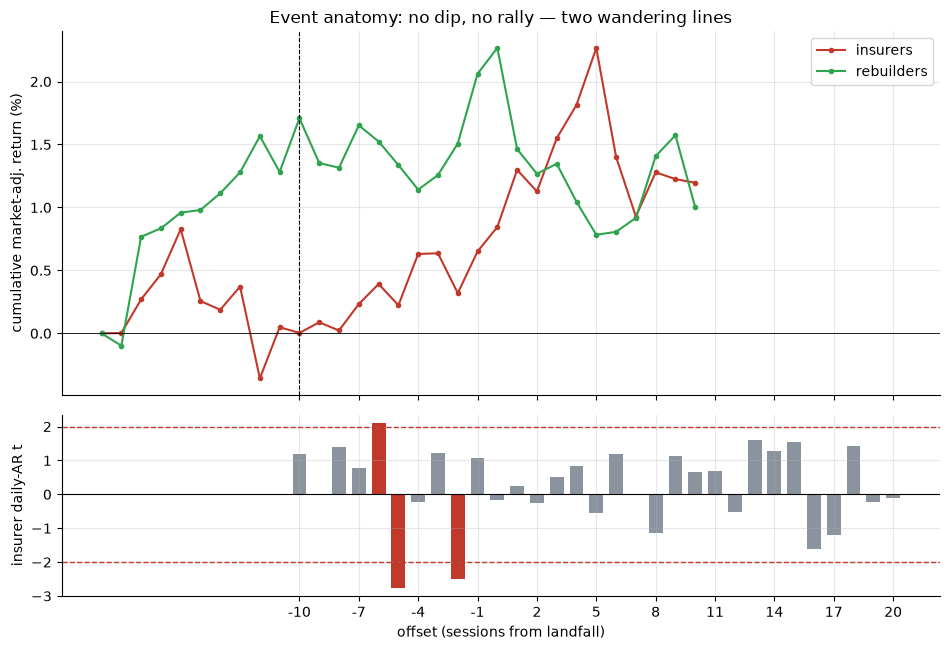

insurer CAR +20: 1.2 %  rebuilder CAR +20: 1.0 %


In [4]:
if HAVE_REAL:
    cp_i = st.car_path_stats(AR_INS, EVENTS['date'], PRE, POST)
    cp_r = st.car_path_stats(AR_REB, EVENTS['date'], PRE, POST)
    ks = list(cp_i.index); ip = list(cp_i['car']*100); rp = list(cp_r['car']*100)
    it = list(cp_i['t'])
else:
    ks, ip, rp = R['offsets'], R['ins_path'], R['reb_path']
    it = [0]*len(ks); it[5] = R['ins_m5_t']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.6, 6.6), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.plot(ks, ip, '-o', color=RED, ms=3, label='insurers')
a1.plot(ks, rp, '-o', color=GREEN, ms=3, label='rebuilders')
a1.axvline(0, c='k', lw=.8, ls='--'); a1.axhline(0, c='k', lw=.6)
a1.set_ylabel('cumulative market-adj. return (%)')
a1.set_title('Event anatomy: no dip, no rally — two wandering lines'); a1.legend()
a2.bar([str(k) for k in ks], it,
       color=[RED if abs(t) >= 2 else GREY for t in it], width=.7)
a2.axhline(0, c='k', lw=.8); a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('insurer daily-AR t'); a2.set_xlabel('offset (sessions from landfall)')
a2.set_xticks(range(0, len(ks), 3)); a2.set_xticklabels([ks[i] for i in range(0, len(ks), 3)])
plt.tight_layout(); plt.show()
print('insurer CAR +20:', round(ip[-1],2), '%  rebuilder CAR +20:', round(rp[-1],2), '%')

> 💡 In plain words: the only bar to cross the line is the insurer daily abnormal return at **−5 sessions** (*t* = -2.77) — a whisper of a pre-storm dip as the forecast firms up, but 1-in-31 crossing by chance is exactly what you'd expect, it has no mechanism that would make it *the* result, and it's gone within days. No cumulative dip or rally survives to the +20 horizon.

### 4d · Robustness — the biggest storms, and two eras

The one place the folklore flickers: sort to the **7 catastrophic (loss-tier 3)** storms and rebuilders finally rally. Is it robust?

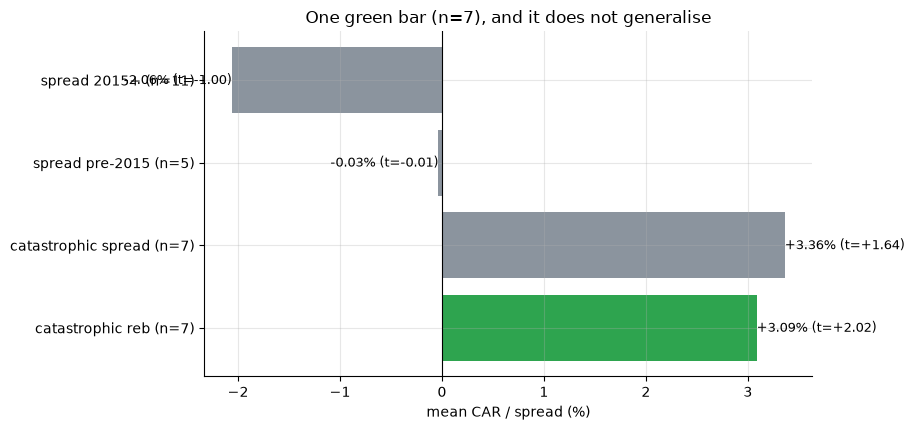

rows: [('catastrophic reb (n=7)', 3.09, 2.02), ('catastrophic spread (n=7)', 3.36, 1.64), ('spread pre-2015 (n=5)', -0.03, -0.01), ('spread 2015+ (n=11)', -2.06, -1.0)]


In [5]:
if HAVE_REAL:
    big3 = EVENTS.loc[EVENTS['loss_tier'] == 3, 'date']
    rb = st.car_stats(AR_REB, big3, PRE, POST, LO, HI)
    lsb = st.long_short_stats(AR_INS, AR_REB, big3, PRE, POST, LO, HI)
    pre = EVENTS.loc[EVENTS['date'] < '2015-01-01', 'date']
    post = EVENTS.loc[EVENTS['date'] >= '2015-01-01', 'date']
    lpre = st.long_short_stats(AR_INS, AR_REB, pre, PRE, POST, LO, HI)
    lpost = st.long_short_stats(AR_INS, AR_REB, post, PRE, POST, LO, HI)
    rows = [('catastrophic reb (n=%d)' % rb['n'], rb['mean']*100, rb['t']),
            ('catastrophic spread (n=%d)' % lsb['n'], lsb['mean_diff']*100, lsb['t']),
            ('spread pre-2015 (n=%d)' % lpre['n'], lpre['mean_diff']*100, lpre['t']),
            ('spread 2015+ (n=%d)' % lpost['n'], lpost['mean_diff']*100, lpost['t'])]
else:
    rows = [(f"catastrophic reb (n={R['tier3_n']})", R['tier3_reb'], R['tier3_reb_t']),
            (f"catastrophic spread (n={R['tier3_n']})", R['tier3_ls'], R['tier3_ls_t']),
            (f"spread pre-2015 (n={R['pre15_n']})", R['pre15_ls'], R['pre15_t']),
            (f"spread 2015+ (n={R['post15_n']})", R['post15_ls'], R['post15_t'])]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
labs = [r[0] for r in rows]; vals = [r[1] for r in rows]; ts = [r[2] for r in rows]
cols = [GREEN if abs(t) >= 2 else GREY for t in ts]
b = ax.barh(labs, vals, color=cols)
for bb, v, t in zip(b, vals, ts):
    ax.annotate(f'{v:+.2f}% (t={t:+.2f})', (v, bb.get_y()+bb.get_height()/2),
                va='center', ha='left' if v>=0 else 'right', fontsize=9)
ax.axvline(0, c='k', lw=.8); ax.set_xlabel('mean CAR / spread (%)')
ax.set_title('One green bar (n=7), and it does not generalise'); plt.tight_layout(); plt.show()
print('rows:', [(l, round(v,2), round(t,2)) for l, v, t in rows])

> 💡 In plain words: the **only** nominally significant number in the study is the rebuilder rally in the 7 catastrophic storms — **+3.09%** at *t* = 2.02. But it's a *post-hoc subgroup* (storms sorted by realised loss), it clears the bar on a hand-picked seven, it doesn't drag the paired spread past significance (*t* = 1.64), and the full-sample spread is wrong-signed and driven by the recent era (2015+ spread -2.06%). It fails the desk's "robust **and** holds across sub-eras" bar — a grain of truth for truly catastrophic storms, not a certifiable edge.

### 4e · The timer — an honest long-short cost sweep

Long rebuilders / short insurers, dollar-neutral, entered at the landfall close (zero look-ahead — the storm is forecast and calendar-known), held `h` sessions; one-way cost × NAV on all 4 legs + 50 bps/yr borrow on the short insurer leg.

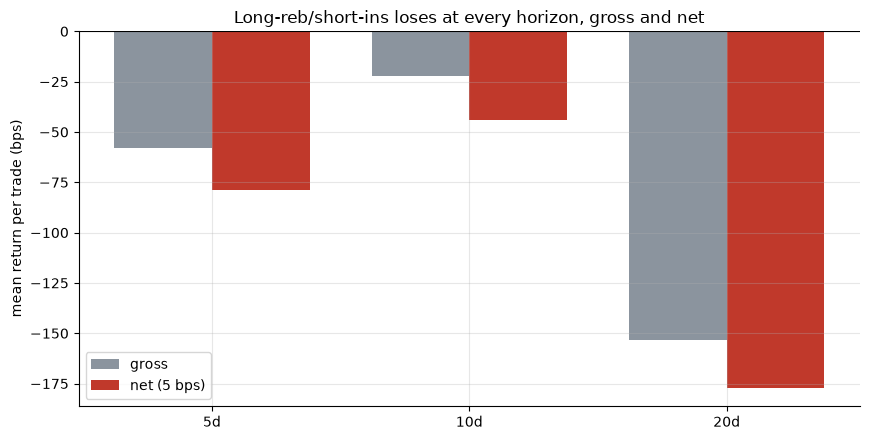

gross (bps): {5: -57.8, 10: -22.2, 20: -153.3}
net 5bps (bps): {5: -78.8, 10: -44.2, 20: -177.2}
t (net): {5: -0.82, 10: -0.41, 20: -1.22}


In [6]:
if HAVE_REAL:
    holds = [5, 10, 20]; gross, net5, ts = [], [], []
    for h in holds:
        g = st.summarize_trades(st.timer(CLOSES, EVENTS['date'], data.INSURERS,
              data.REBUILDERS, hold=h, cost_bps=0.0), 'ret_gross')
        n5 = st.summarize_trades(st.timer(CLOSES, EVENTS['date'], data.INSURERS,
              data.REBUILDERS, hold=h, cost_bps=5.0), 'ret_net')
        gross.append(g['mean_bps']); net5.append(n5['mean_bps']); ts.append(n5['t'])
else:
    holds = sorted(R['timer'])
    gross = [R['timer'][h][0] for h in holds]
    net5 = [R['timer'][h][1] for h in holds]
    ts = [R['timer'][h][2] for h in holds]
fig, ax = plt.subplots(figsize=(8.8, 4.5))
x = np.arange(len(holds)); w = 0.38
ax.bar(x - w/2, gross, width=w, color=GREY, label='gross')
ax.bar(x + w/2, net5, width=w, color=RED, label='net (5 bps)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_ylabel('mean return per trade (bps)')
ax.set_title('Long-reb/short-ins loses at every horizon, gross and net')
ax.legend(); plt.tight_layout(); plt.show()
print('gross (bps):', dict(zip(holds, [round(v,1) for v in gross])))
print('net 5bps (bps):', dict(zip(holds, [round(v,1) for v in net5])))
print('t (net):', dict(zip(holds, [round(t,2) for t in ts])))

> 💡 In plain words: at 5 bps costs the trade nets **-79 / -44 / -177 bps** at 5/10/20-day holds — negative everywhere (worst *t* = -1.22), win rate ≤ 44%. H₄ is not supported: the book is short the leg that drifts up and long the leg that goes nowhere. No edge to charge costs against.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic world: an SPY-like market + 5 single names + a TUNABLE planted market-adjusted drift (insurers −`edge`/day, rebuilders +`edge`/day) decaying over 15 sessions. The null (edge=0) is checked over **20 seeds**.

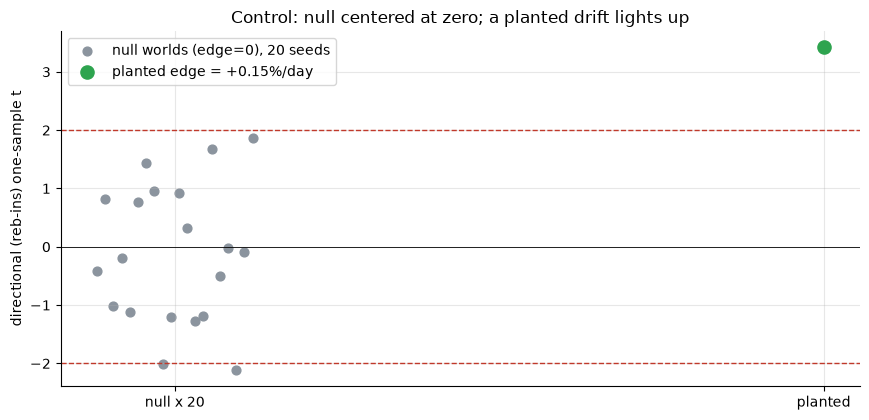

null: mean t = -0.12 (sd 1.19), |t|>=2 in 2/20 seeds  |  planted t = +3.42


In [7]:
null_ts = []
for s_ in range(20):
    cl, ev = data.synthetic_world(edge=0.0, seed=843 + s_)
    null_ts.append(st.synthetic_detect(cl, ev, data.INSURERS, data.REBUILDERS)['ls_t'])
null_ts = np.asarray(null_ts)
cl, ev = data.synthetic_world(edge=0.0015, seed=843)
planted = st.synthetic_detect(cl, ev, data.INSURERS, data.REBUILDERS)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted['ls_t']], color=GREEN, s=90, zorder=5,
           label='planted edge = +0.15%/day')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.6)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('directional (reb-ins) one-sample t')
ax.set_title('Control: null centered at zero; a planted drift lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts) >= 2).sum()}/20 seeds  |  planted t = {planted["ls_t"]:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.12 (sd 1.19); the 2/20 that cross the bar are the ~5% nominal false-positive rate at n=16, **not** a bias (it's centered at zero). A planted +0.15%/day drift reads t = 3.42 (insurers t = -2.64, rebuilders t = 1.81). The machinery is unbiased — the real-tape nulls are genuine. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — insurers **+1.15%** (*t* = +1.48), rebuilders **-0.28%** (*t* = -0.25), paired spread **-1.43%** (*t* = -0.88) — three wrong signs, none significant, placebo *p* = 0.379. The lone significant cut (tier-3 rebuilder rally, *t* = 2.02, n=7) is a post-hoc subgroup failing the sub-era bar.
- **Tradability `MIRAGE`** — long-reb/short-ins loses at every horizon (5/10/20d), gross and net (worst -177 bps, *t* = -1.22). No edge to charge costs against.
- **"Does the market read the Waffle House Index?" `BUSTED`** — a *forecast* disaster is priced before landfall, the post-event reaction is flat-to-backwards in the obvious large-caps, and n=16 is low power. A real, smaller, more localized effect (a regional insurer, a homebuilder, the reinsurance/cat-bond market) is not ruled out at this size.

## 6 · Going further

- **Power is the honest limitation.** n=16 independent events is small for a modest hypothesized effect that anticipation has mostly eaten. A pre-registered extension (more storms, or a broader disaster register — wildfires, floods) with the same discipline is the natural next step.
- **Narrower instruments** — a single hard-hit regional insurer, a homebuilder rather than a big-box retailer, or the reinsurance / cat-bond market where risk actually re-prices — might carry a signal a diversified large-cap basket cannot.
- **Dedup map:** [283-hurricane-season](../../283-hurricane-season/) (the seasonal calendar, not the event), [316-bank-failure](../../316-bank-failure/) (same machinery, a *surprise* shock), [313-geopolitical-shock](../../313-geopolitical-shock/) (war/terror) and [707-plane-crash-effect](../../707-plane-crash-effect/) (the closest cousin — a disaster calendar and a sector extra-drop). Same event-study rails, different trigger and exposed sectors.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*